In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown

# Set standard plotting aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

# Define Netflix-themed colors for consistent visualization
NETFLIX_RED = '#E50914'
NETFLIX_DARK = '#221F1F'
SECONDARY_COLOR = '#00A896' # Teal for contrast in line plots

display(Markdown("## 1. Setup and Data Loading"))
display(Markdown("---"))

try:
    # Load the dataset. Ensure 'Netflix Dataset 1.csv' is uploaded to your Colab session.
    df = pd.read_csv('Netflix Dataset 1.csv')
    display(Markdown("✅ **Dataset loaded successfully.**"))
except FileNotFoundError:
    display(Markdown("❌ **Error:** 'Netflix Dataset 1.csv' not found. Please upload the file to your Colab environment."))
    exit()

display(Markdown("\n### Initial Data Overview (Head and Info)"))
display(df.head())
df.info()


## 1. Setup and Data Loading

---

✅ **Dataset loaded successfully.**


### Initial Data Overview (Head and Info)

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [7]:
display(Markdown("## 2. Data Preprocessing and Cleaning"))
display(Markdown("---"))

# --- 2.1 Date Cleaning and Year Extraction ---
# Drop rows where 'Release_Date' is missing, as temporal analysis requires this field.
df.dropna(subset=['Release_Date'], inplace=True)
display(Markdown(f"Removed missing `Release_Date` rows. Remaining records: {len(df)}"))

# Extract year from Release_Date. 'coerce' handles any unexpected date formats.
df['Release_Year'] = pd.to_datetime(df['Release_Date'].str.strip(), errors='coerce').dt.year

# Filter out rows where year extraction failed and convert to integer
df.dropna(subset=['Release_Year'], inplace=True)
df['Release_Year'] = df['Release_Year'].astype(int)
display(Markdown("✅ **`Release_Year`** column created and cleaned."))

# --- 2.2 Handling Missing Categorical Data ---
# Fill missing 'Country' values with 'Unknown'
df['Country'] = df['Country'].fillna('Unknown')
display(Markdown("✅ Missing `Country` values filled with 'Unknown'."))

# --- 2.3 Filtering for Analysis ---
# Create the primary DataFrame containing only Movies and TV Shows
df_analysis = df[df['Category'].isin(['Movie', 'TV Show'])].copy()

display(Markdown(f"\n✅ **Final Analysis Data Size:** **{len(df_analysis)}** records."))
display(Markdown("---"))


## 2. Data Preprocessing and Cleaning

---

Removed missing `Release_Date` rows. Remaining records: 7779

✅ **`Release_Year`** column created and cleaned.

✅ Missing `Country` values filled with 'Unknown'.


✅ **Final Analysis Data Size:** **7779** records.

---

## 3. Analysis of Content Distribution Over Time

---

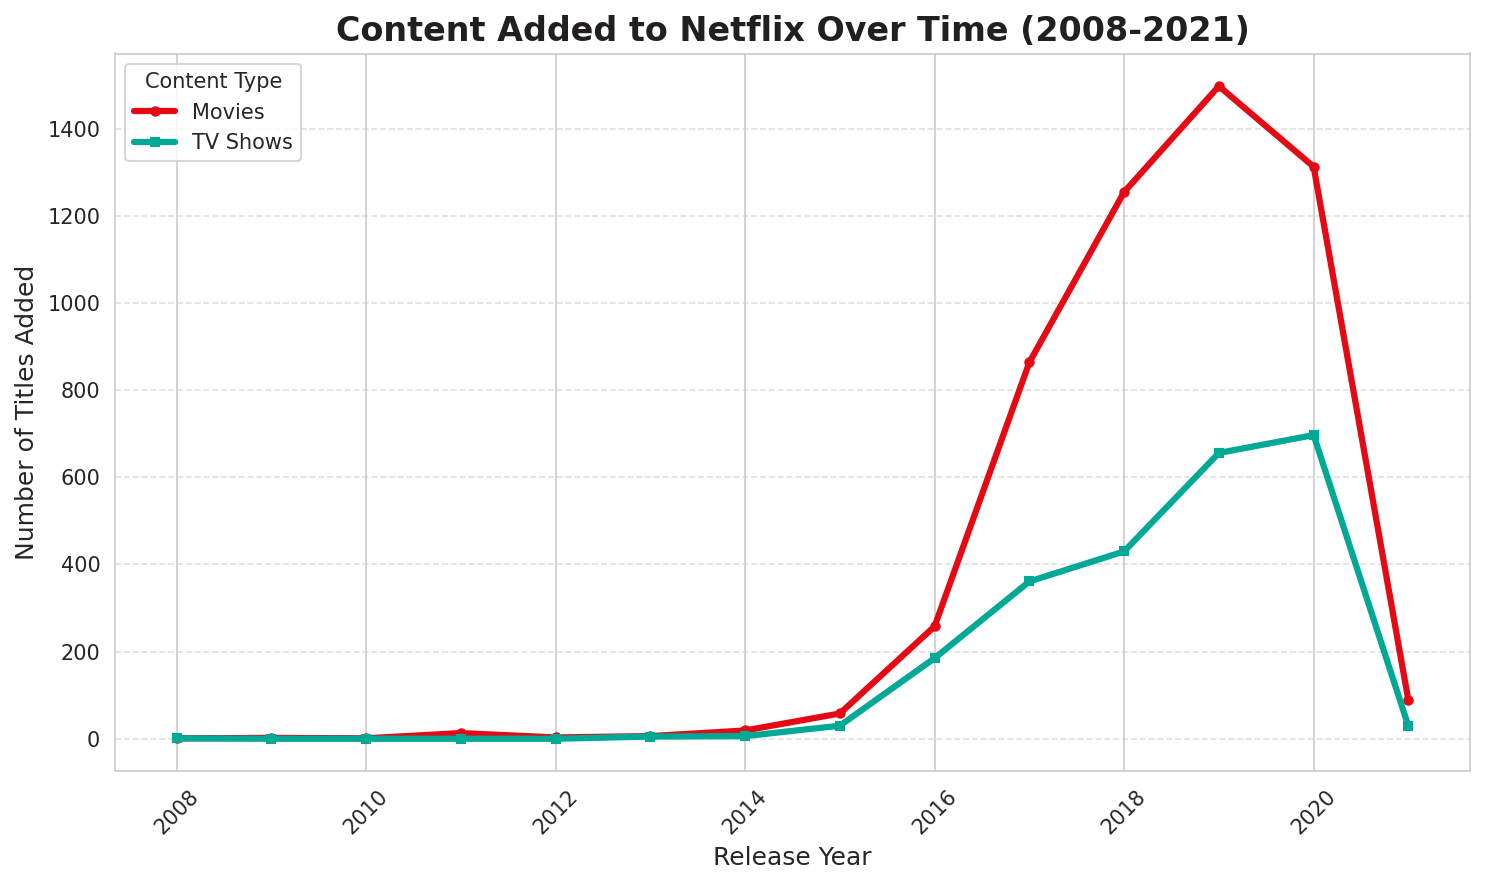


**💡 Insight:** The chart reveals a dramatic acceleration in **TV Show** additions starting around 2016, indicating a strategic shift towards long-form, binge-worthy content.

In [3]:
display(Markdown("## 3. Analysis of Content Distribution Over Time"))
display(Markdown("---"))

# Group by release year and category to count titles added
content_trend = df_analysis.groupby(['Release_Year', 'Category']).size().reset_index(name='Count')

# Pivot the table for easier plotting with separate lines for Movie and TV Show
content_pivot = content_trend.pivot(index='Release_Year', columns='Category', values='Count').fillna(0)

# Filter for the relevant period (2008 onwards, as detailed in the problem statement)
content_pivot = content_pivot[content_pivot.index >= 2008]

plt.figure()
plt.plot(content_pivot.index, content_pivot['Movie'], label='Movies', color=NETFLIX_RED, linewidth=3, marker='o', markersize=4)
plt.plot(content_pivot.index, content_pivot['TV Show'], label='TV Shows', color=SECONDARY_COLOR, linewidth=3, marker='s', markersize=4)
plt.title('Content Added to Netflix Over Time (2008-2021)', fontsize=16, fontweight='bold', color=NETFLIX_DARK)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.legend(title='Content Type', frameon=True)
plt.xticks(content_pivot.index[::2], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(Markdown("\n**💡 Insight:** The chart reveals a dramatic acceleration in **TV Show** additions starting around 2016, indicating a strategic shift towards long-form, binge-worthy content."))


## 4. Genre Popularity Analysis

---

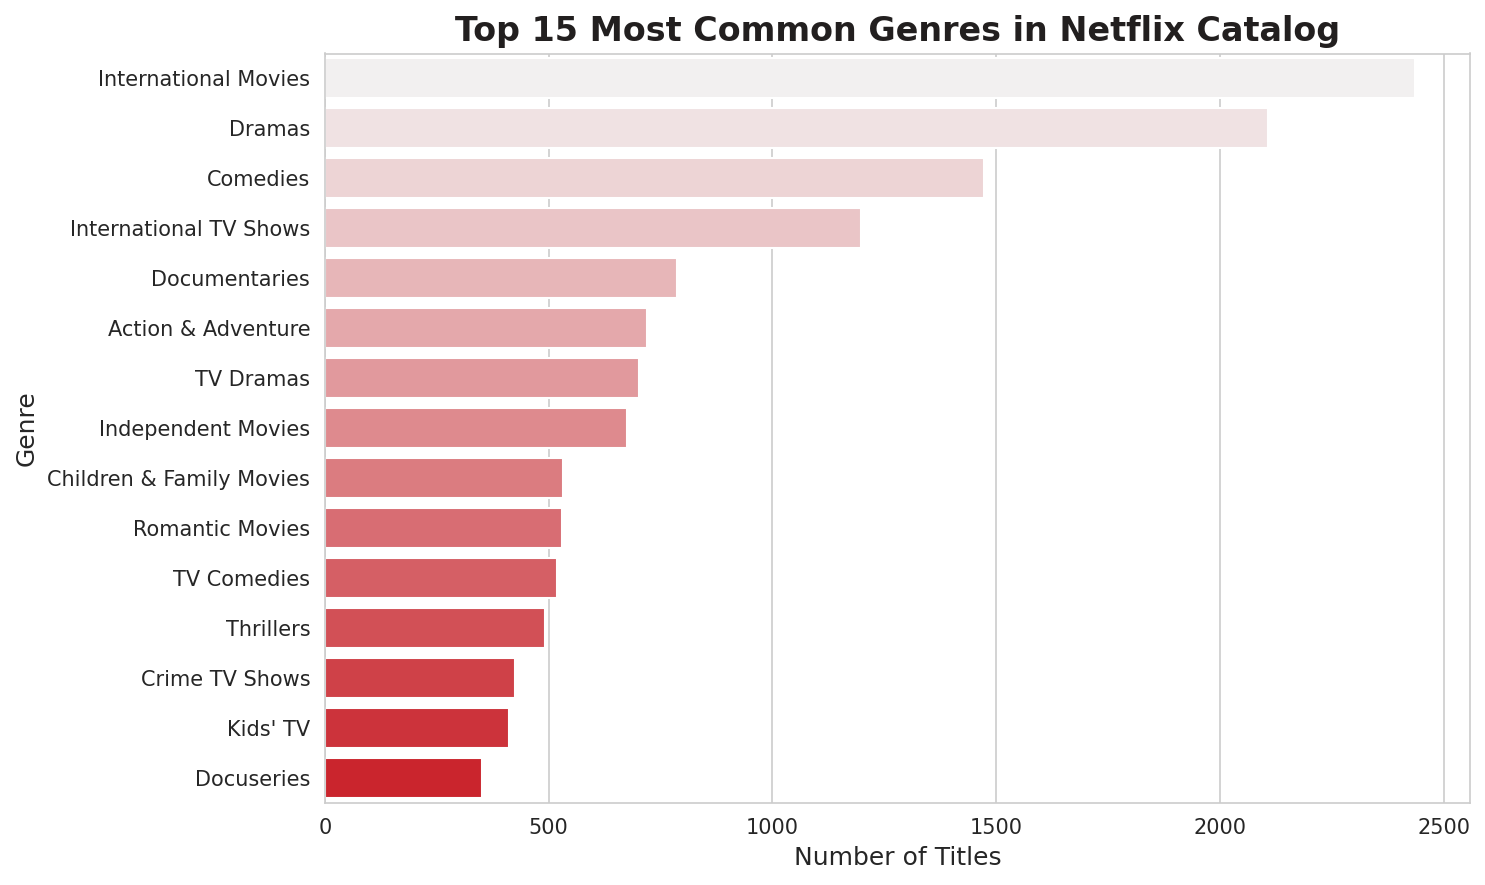


**💡 Insight:** **International Movies** and **Dramas** lead the list, confirming Netflix's strategy of acquiring global content and focusing on universally appealing dramatic narratives.

In [8]:
display(Markdown("## 4. Genre Popularity Analysis"))
display(Markdown("---"))

# Function to safely split and count genres from the 'Type' column
def count_categories(df, column):
    # Split by ', ' and flatten the resulting list of lists
    categories = df[column].str.split(', ').explode()
    return Counter(categories.dropna())

genre_counts = count_categories(df_analysis, 'Type')

# Convert to DataFrame and select top 15 genres
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)
top_genres = genre_df.head(15)

# Visualize the top 15 genres
plt.figure()
sns.barplot(x='Count', y='Genre', data=top_genres, hue='Genre', legend=False,
            palette=sns.light_palette(NETFLIX_RED, n_colors=15, reverse=False))
plt.title('Top 15 Most Common Genres in Netflix Catalog', fontsize=16, fontweight='bold', color=NETFLIX_DARK)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

display(Markdown("\n**💡 Insight:** **International Movies** and **Dramas** lead the list, confirming Netflix's strategy of acquiring global content and focusing on universally appealing dramatic narratives."))


## 5. Global Content Contribution Analysis

---

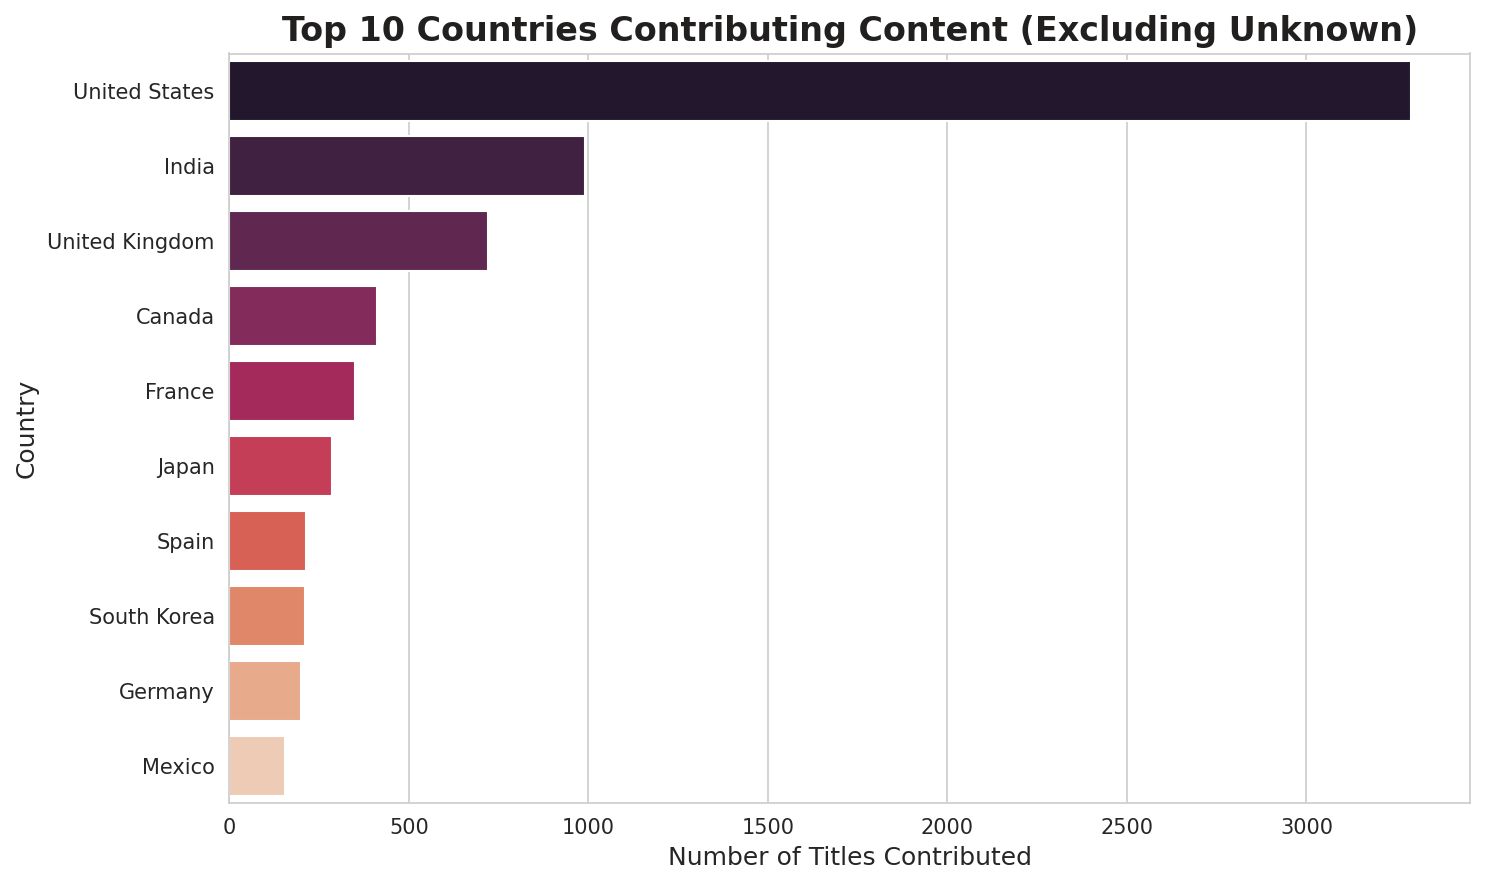


**💡 Insight:** While the **United States** is dominant, the strong presence of **India** and the **United Kingdom** demonstrates successful investment in diverse, high-volume international production hubs.

In [9]:
display(Markdown("## 5. Global Content Contribution Analysis"))
display(Markdown("---"))

# Function to safely split and count countries
def count_countries(df):
    countries = df['Country'].str.split(', ', expand=True).stack().str.strip()
    return Counter(countries.dropna())

# Exclude 'Unknown' countries and count the rest
country_counts = count_countries(df_analysis[df_analysis['Country'] != 'Unknown'])

# Convert to DataFrame and select top 10
country_df = pd.DataFrame(country_counts.items(), columns=['Country', 'Count']).sort_values(by='Count', ascending=False)
top_countries = country_df.head(10)

# Visualize the top 10 contributing countries
plt.figure()
sns.barplot(x='Count', y='Country', data=top_countries, hue='Country', legend=False, palette='rocket')
plt.title('Top 10 Countries Contributing Content (Excluding Unknown)', fontsize=16, fontweight='bold', color=NETFLIX_DARK)
plt.xlabel('Number of Titles Contributed', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

display(Markdown("\n**💡 Insight:** While the **United States** is dominant, the strong presence of **India** and the **United Kingdom** demonstrates successful investment in diverse, high-volume international production hubs."))


In [6]:
display(Markdown("## 6. Strategic Recommendations for Content Strategy"))
display(Markdown("---"))

recommendations = [
    ("Accelerate TV Show Investment", "The growth trend shows TV Shows are essential for retention. **Continue prioritizing multi-season series** over one-off movies to maintain subscriber engagement (lowering churn)."),
    ("Diversify Sub-Genres", "While Dramas are voluminous, analyze niche but high-engagement genres (e.g., **Documentaries, Stand-Up Comedy, Reality TV**) to capture underserved audience segments and diversify content appeal."),
    ("Deepen Global Footprint", "Increase original production investment in rising content powerhouses like **India, South Korea, and Spain** to secure local relevance and mitigate over-reliance on US-centric content."),
]

display(Markdown("Based on the analysis of content trends and country contributions, here are the key strategic recommendations:"))

for title, text in recommendations:
    display(Markdown(f"#### **{title}**"))
    display(Markdown(f"*{text}*"))

display(Markdown("\n---\n"))
display(Markdown("🎉 **Project Analysis Complete!** You can now present these findings and visualizations."))


## 6. Strategic Recommendations for Content Strategy

---

Based on the analysis of content trends and country contributions, here are the key strategic recommendations:

#### **Accelerate TV Show Investment**

*The growth trend shows TV Shows are essential for retention. **Continue prioritizing multi-season series** over one-off movies to maintain subscriber engagement (lowering churn).*

...

*While Dramas are voluminous, analyze niche but high-engagement genres (e.g., **Documentaries, Stand-Up Comedy, Reality TV**) to capture underserved audience segments and diversify content appeal.*

#### **Deepen Global Footprint**

*Increase original production investment in rising content powerhouses like **India, South Korea, and Spain** to secure local relevance and mitigate over-reliance on US-centric content.*


---


🎉 **Project Analysis Complete!** You can now present these findings and visualizations.